In [1]:
%cd ../../

/Users/macos/Uni/1st_year/period_2/IntroML/homework


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

## Task a & b

In [4]:
path_1 = "E1/data/d1.csv"
path_2 = "E1/data/d2.csv"
path_3 = "E1/data/d3.csv"
path_4 = "E1/data/d4.csv"

In [5]:
def add_1s(x):
    Xs = [x, np.ones_like(x)]
    x = np.vstack(Xs).T

    return x

In [132]:
i = 3

path = eval(f"path_{i}")

df = pd.read_csv(path)

X = add_1s(df['x'].to_numpy())

model = sm.OLS(df['y'], X)
results = model.fit()

In [133]:
df.head()

,x,y
0,10,7.46
1,8,6.77
2,13,12.74
3,9,7.11
4,11,7.81


In [134]:
results.summary()

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     17.97
Date:                Mon, 13 Nov 2023   Prob (F-statistic):            0.00218
Time:                        00:09:31   Log-Likelihood:                -16.838
No. Observations:                  11   AIC:                             37.68
Df Residuals:                       9   BIC:                             38.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.4997      0.118      4.239      0.002       0.233       0.766
const          3.0025      1.124      2.670      0.026       0.459       5.546
==============================================================================
Omnibus:                       19.540   Durbin-Watson:                   2.144
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               13.478
Skew:                           2.041   Prob(JB):                      0.00118
Kurtosis:                       6.571   Cond. No.                         29.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [135]:
Xplot = add_1s(np.linspace(0, 20, 1000))
yplot = results.predict(Xplot)

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Text(0.5, 1.0, 'Fitted line and Data of dataset 3')

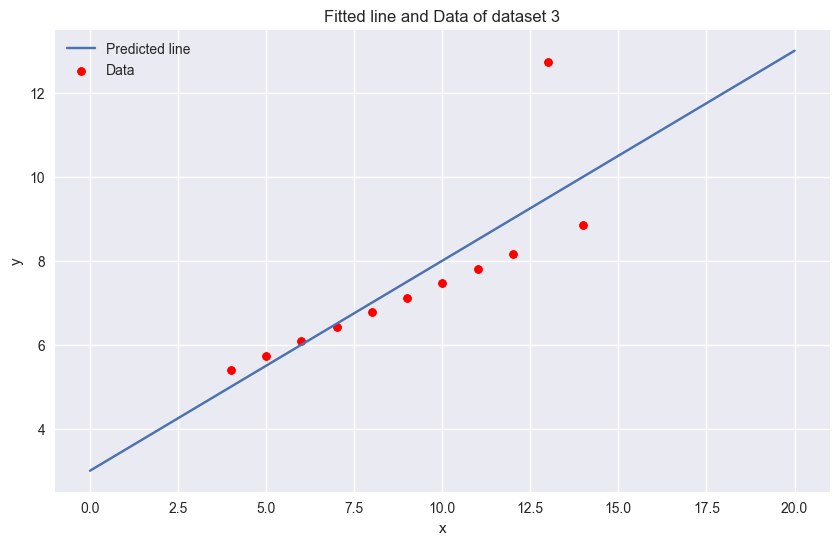

In [136]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(Xplot[:, 0], yplot)
sns.scatterplot(df, x='x', y='y', ax=ax, c='r')
ax.legend(["Predicted line", "Data"])
ax.set_title(f"Fitted line and Data of dataset {i}")

## Task c

In [137]:
def cal_res_Stu(df: pd.DataFrame, residuals: np.ndarray, dof: int = 2) -> np.ndarray:
    # Calculate X_design
    X = df['x'].to_numpy()
    ones = np.ones_like(X)

    X_design = np.vstack([ones, X]).T
    
    # Calculate leverage vector
    H = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T
    leverage = H.diagonal()

    # Calculate estimated sigma
    sigma_sq_estimated = 1/(len(residuals) - dof) * (residuals ** 2).sum()

    # Calculate Studentized residuals
    residuals_Stu = residuals / np.sqrt(sigma_sq_estimated * (1 - leverage))

    return residuals_Stu

### Calculate things

In [138]:
y_pred = results.predict(add_1s(df['x']))
residuals = df['y'] - y_pred
residuals_Stu = cal_res_Stu(df, residuals)

df_res = pd.DataFrame({
    'Fitted value': y_pred,
    'Residual': residuals,
    'Studentized_Residual': residuals_Stu
})

/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

Text(0.5, 1.0, 'Studentized residual plot')

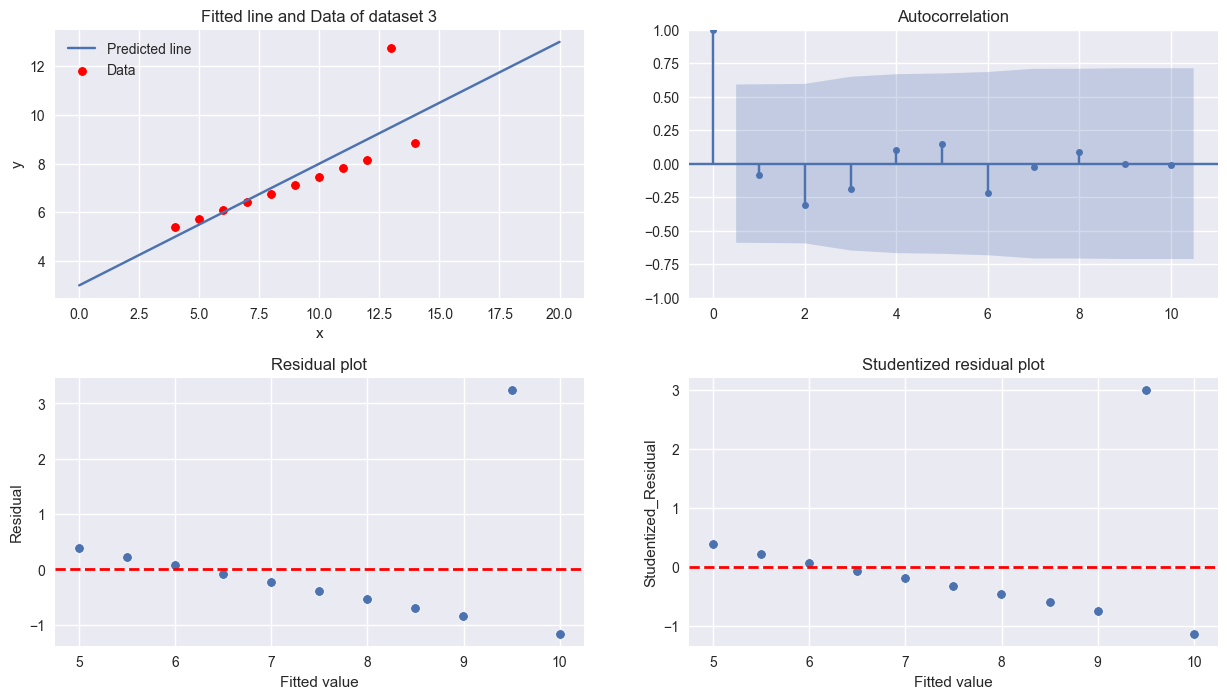

In [139]:
fig = plt.figure(figsize=(15, 8))
fig.subplots_adjust(wspace=0.2, hspace=0.3)

ncols, nrows = 2, 2

# Plot points and fitted

ax = fig.add_subplot(nrows, ncols, 1)
ax.plot(Xplot[:, 0], yplot)
sns.scatterplot(df, x='x', y='y', ax=ax, c='r')
ax.legend(["Predicted line", "Data"])
ax.set_title(f"Fitted line and Data of dataset {i}")

# Plot ACF plot
ax = fig.add_subplot(nrows, ncols, 2)

plot_acf(residuals, ax=ax)

# Plot residual plot
ax = fig.add_subplot(nrows, ncols, 3)

sns.scatterplot(df_res, x='Fitted value', y='Residual', ax=ax)
ax.axhline(0, linestyle='--', linewidth=2, c='r')
ax.set_title("Residual plot")

# Get Pearson correlation
# print(f"Pearson correlation of 'x' and residuals: {np.corrcoef(df['x'], residuals)[0, 1]:.4f}")

# Plot Studentized residuals plot
ax = fig.add_subplot(nrows, ncols, 4)
sns.scatterplot(df_res, x='Fitted value', y='Studentized_Residual', ax=ax)
ax.axhline(0, linestyle='--', linewidth=2, c='r')
ax.set_title("Studentized residual plot")